,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


(4372, 52)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 4372 non-null   int64  
 1   Recency                    4372 non-null   int64  
 2   Frequency                  4372 non-null   int64  
 3   MonetaryTotal              4372 non-null   float64
 4   MonetaryAvg                4372 non-null   float64
 5   MonetaryStd                4372 non-null   float64
 6   MonetaryMin                4372 non-null   float64
 7   MonetaryMax                4372 non-null   float64
 8   TotalQuantity              4372 non-null   int64  
 9   AvgQuantityPerTransaction  4372 non-null   float64
 10  MinQuantity                4372 non-null   int64  
 11  MaxQuantity                4372 non-null   int64  
 12  CustomerTenureDays         4372 non-null   int64  
 13  FirstPurchaseDaysAgo       4372 non-n

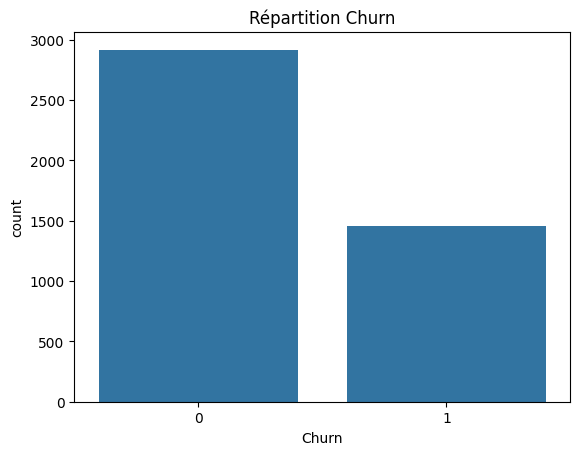

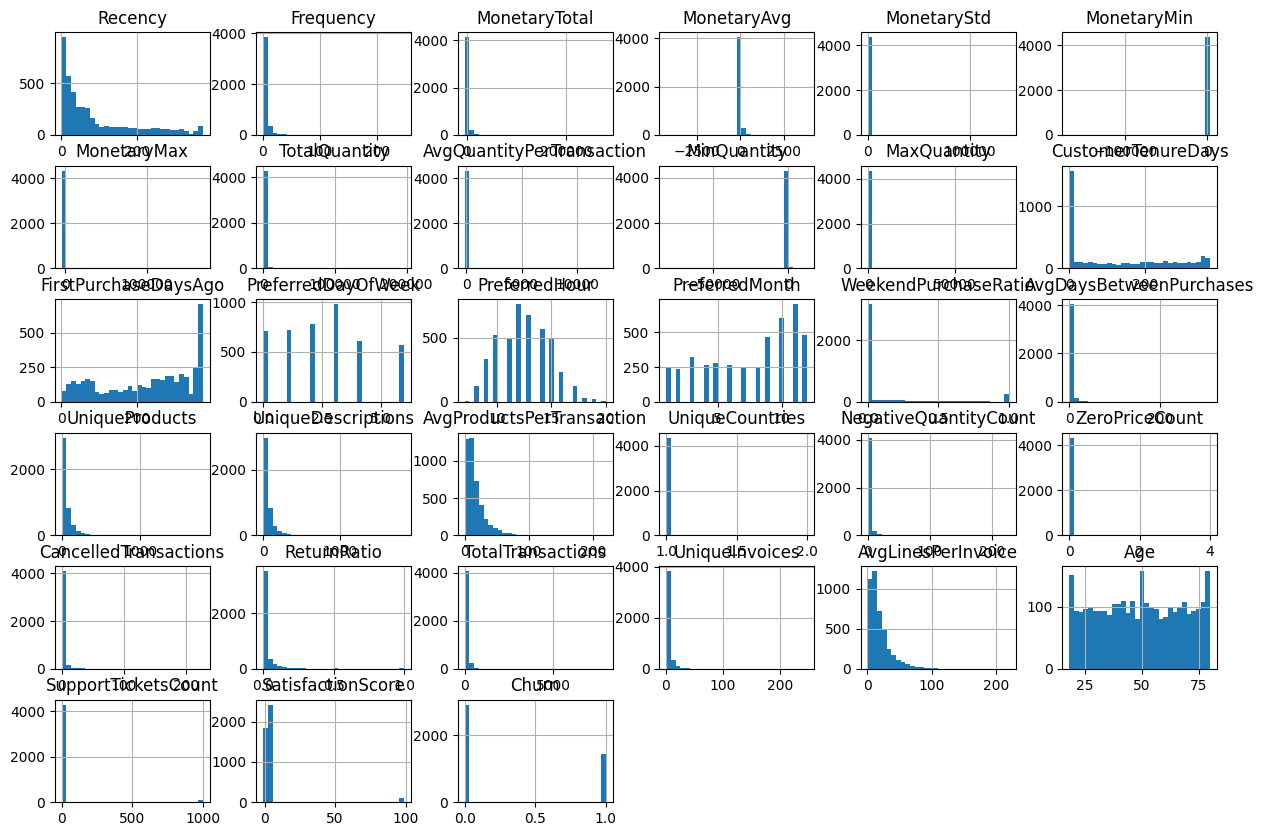

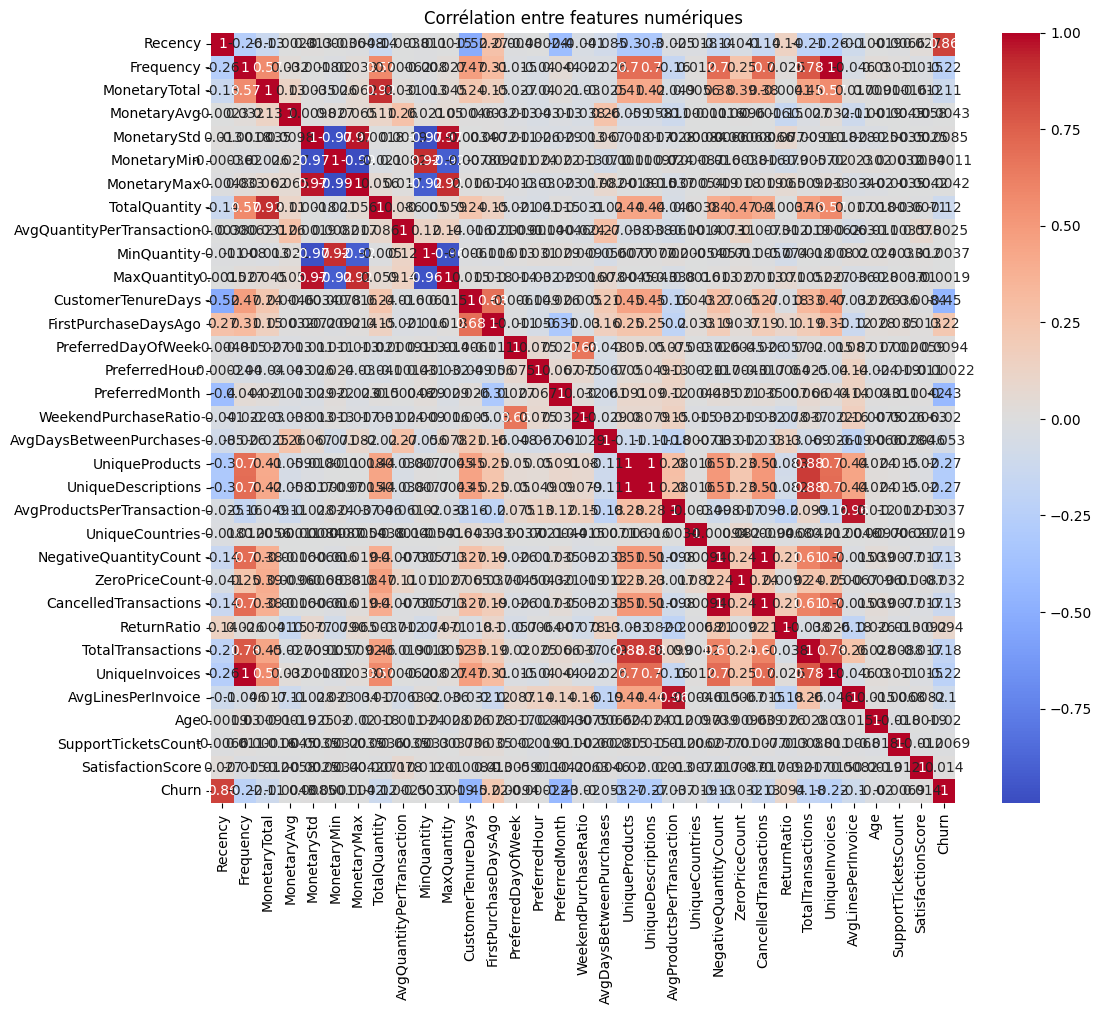

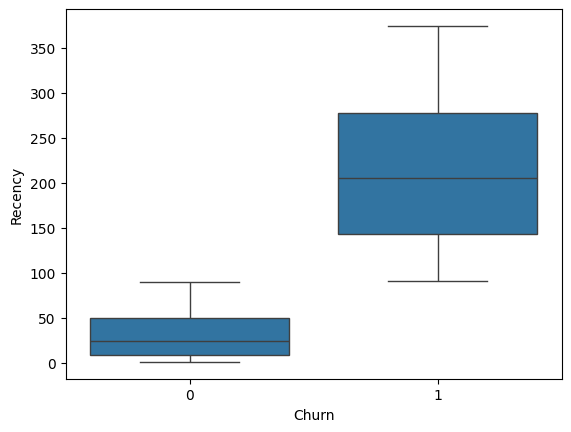

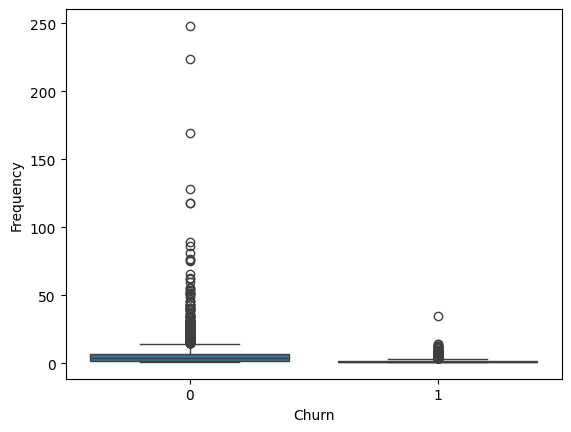

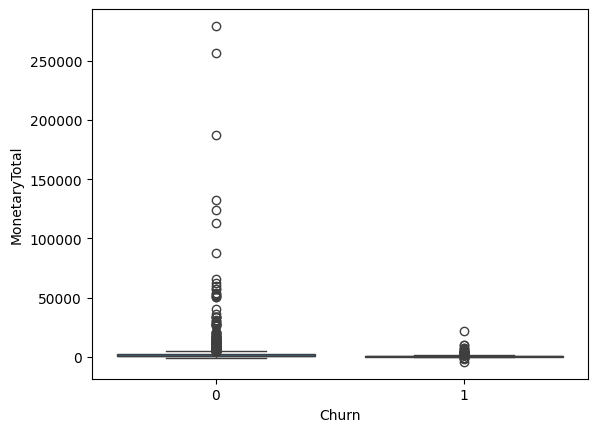

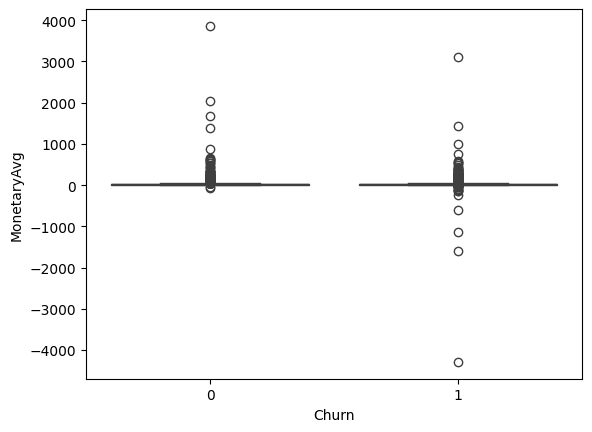

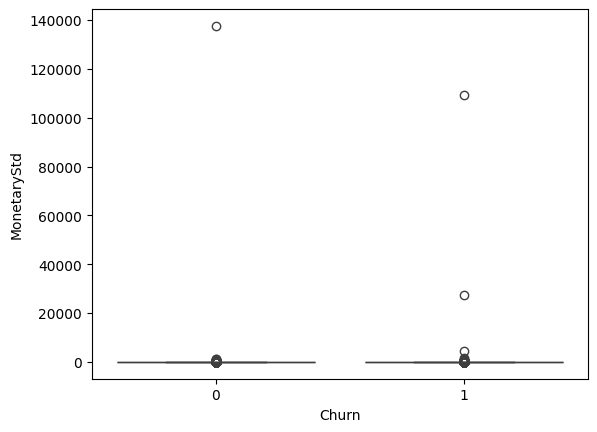

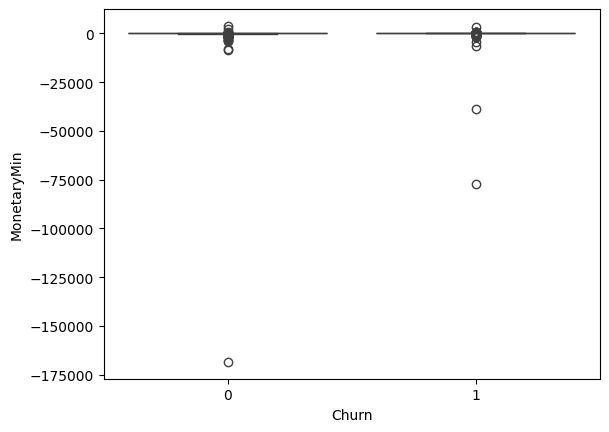

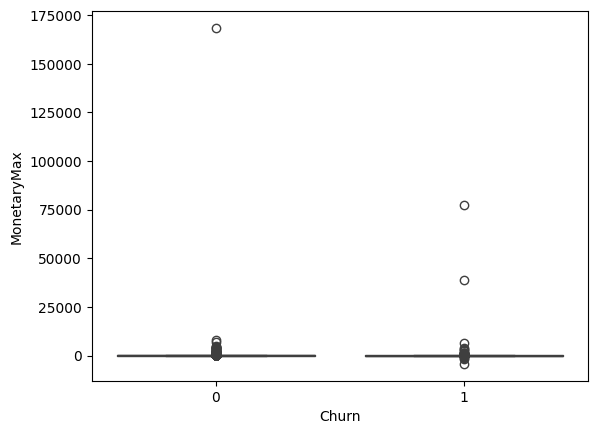

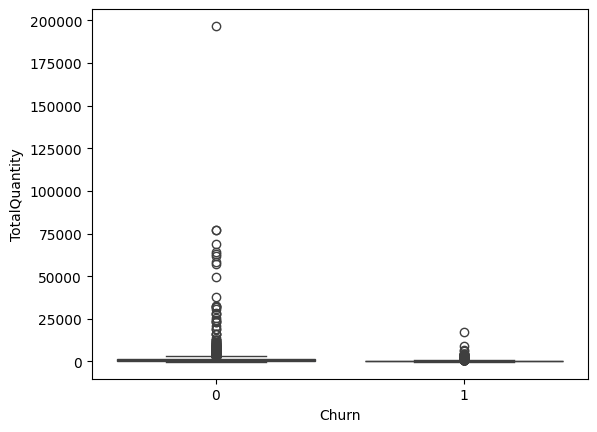

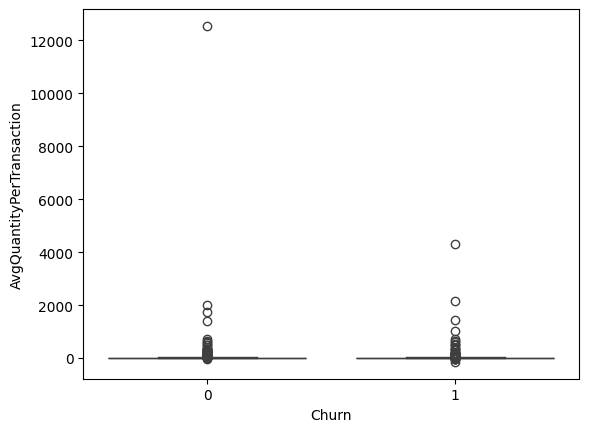

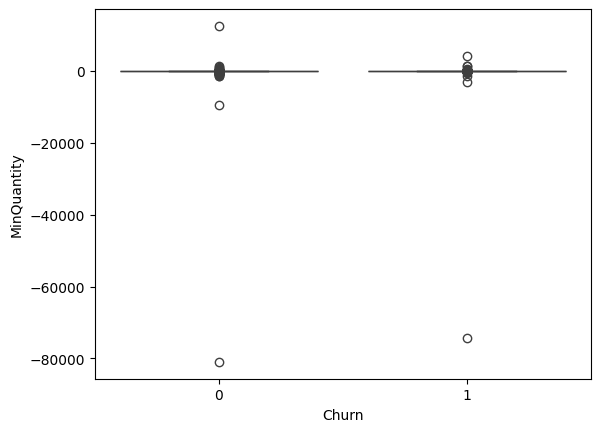

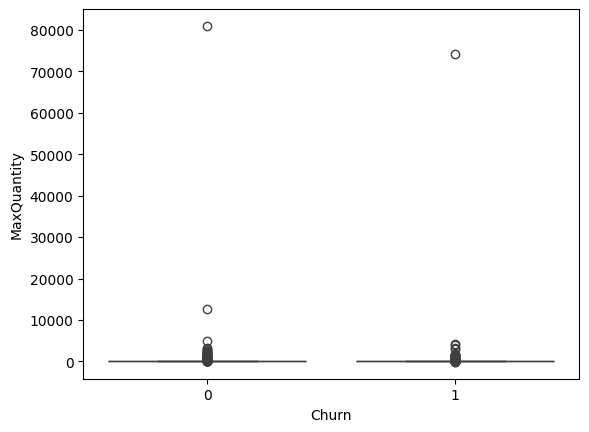

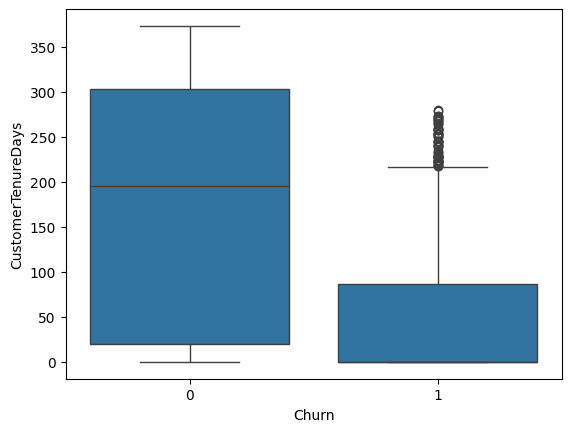

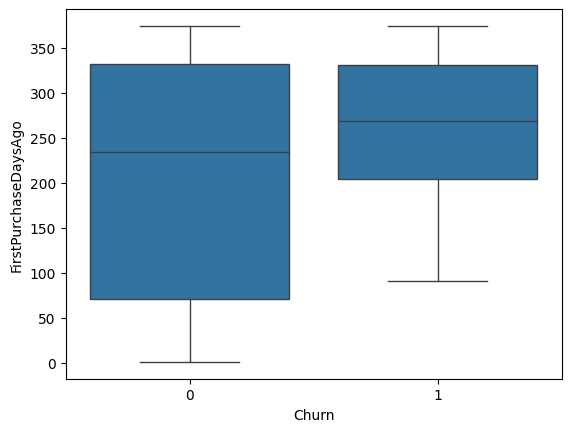

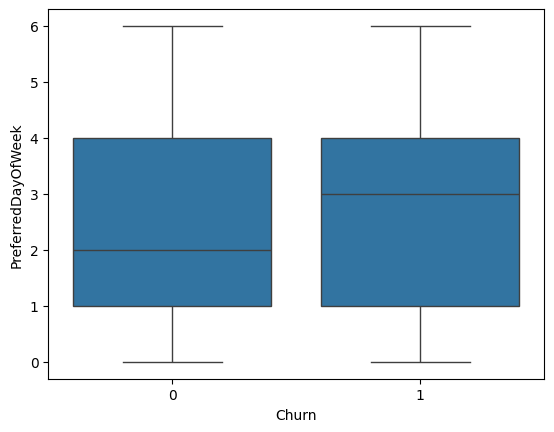

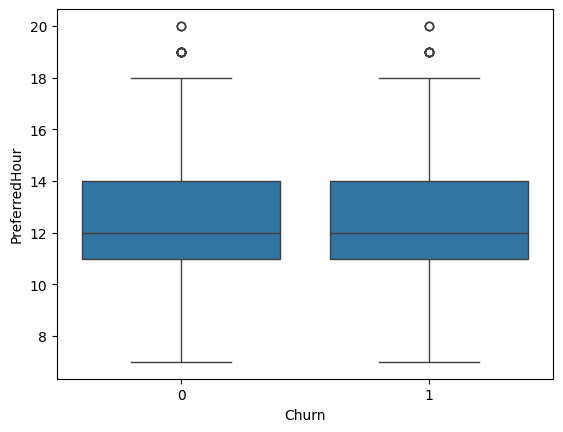

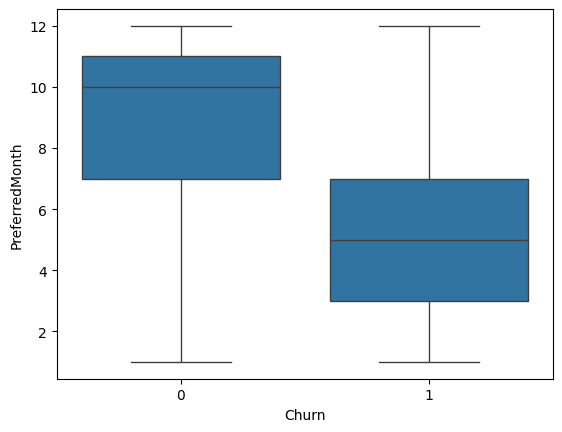

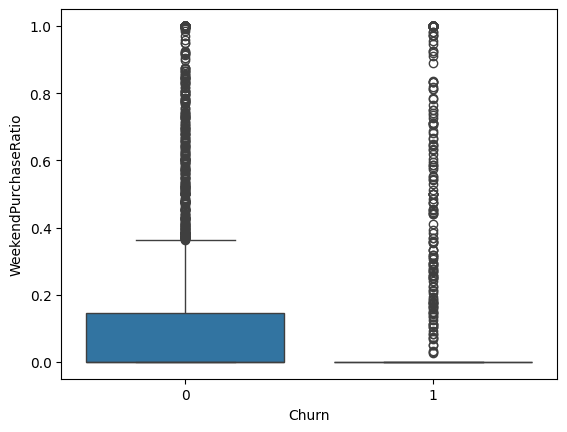

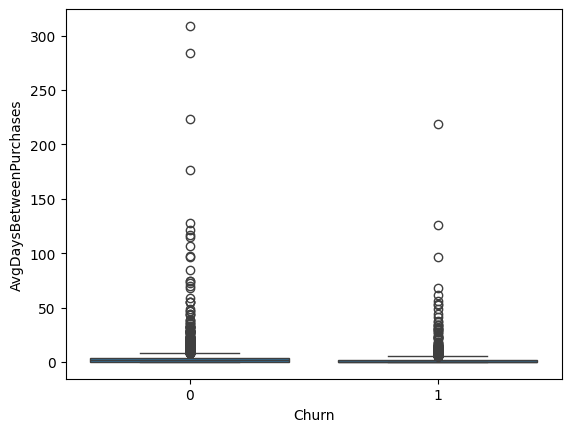

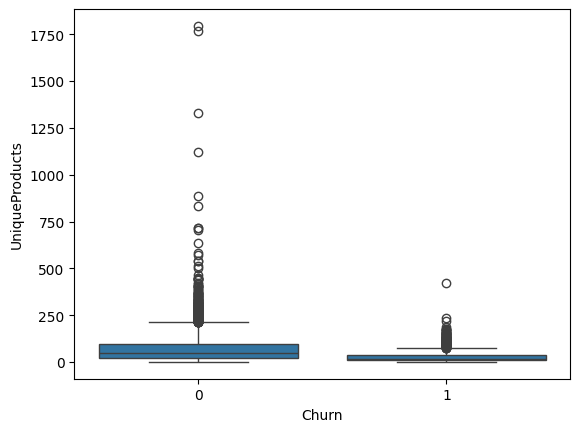

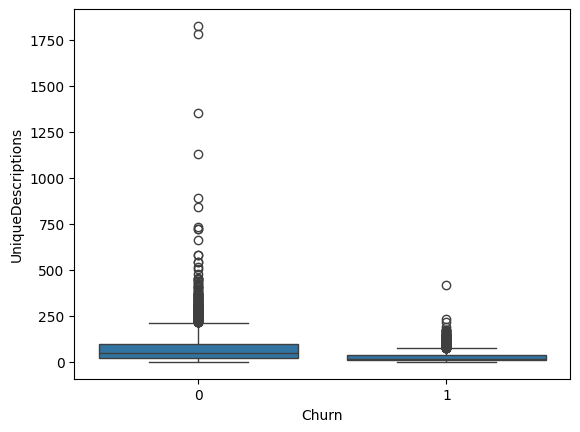

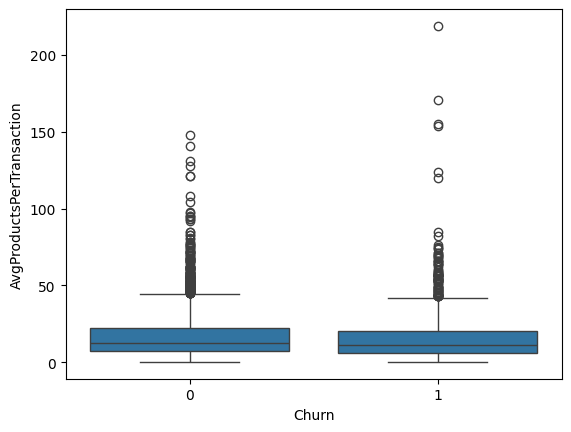

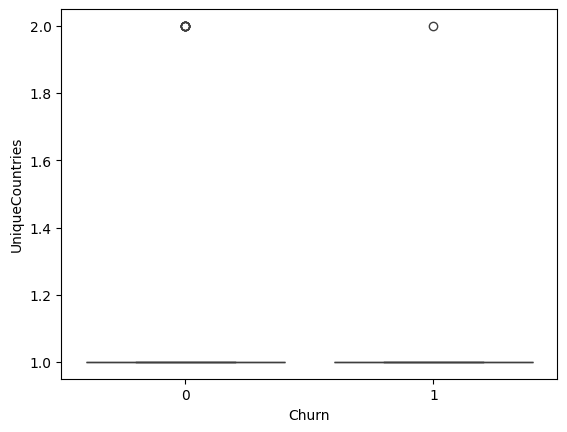

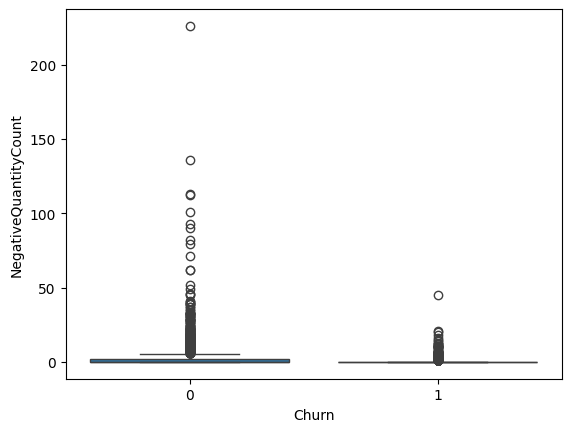

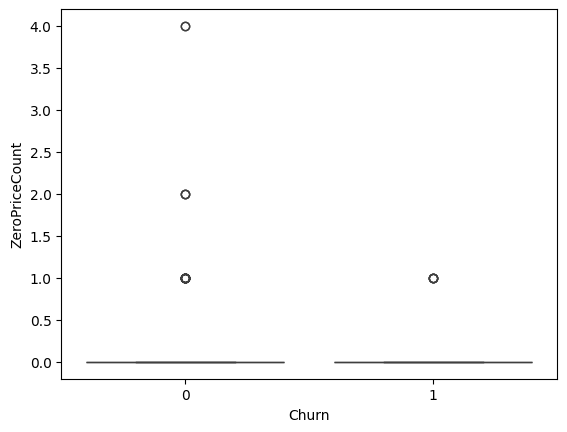

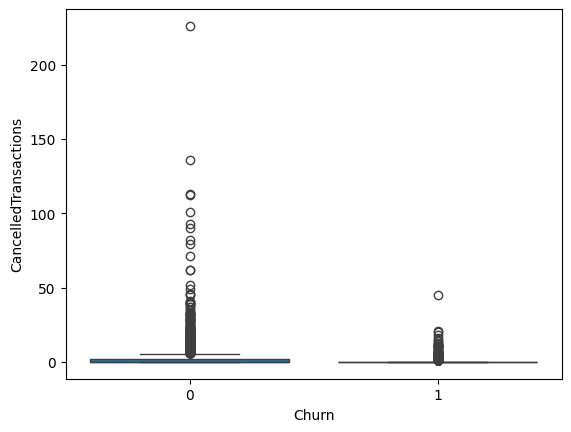

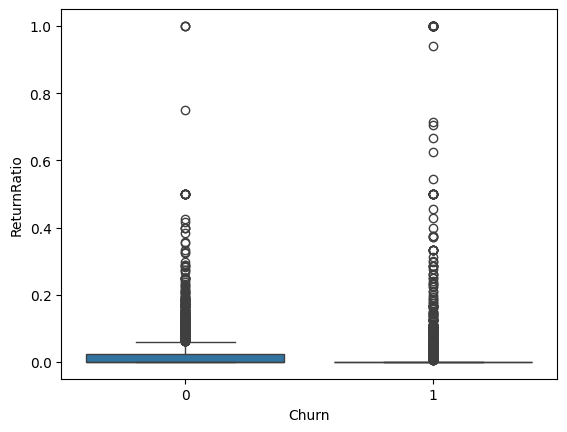

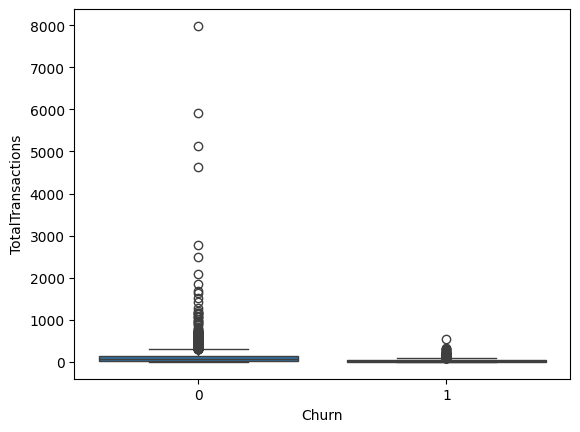

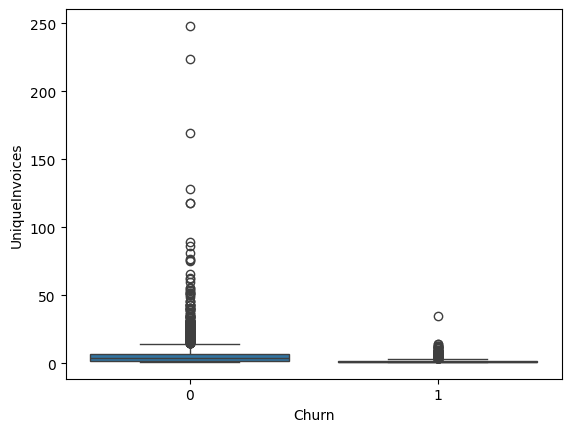

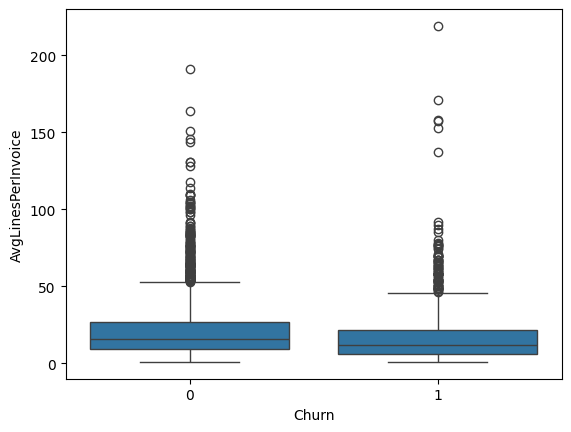

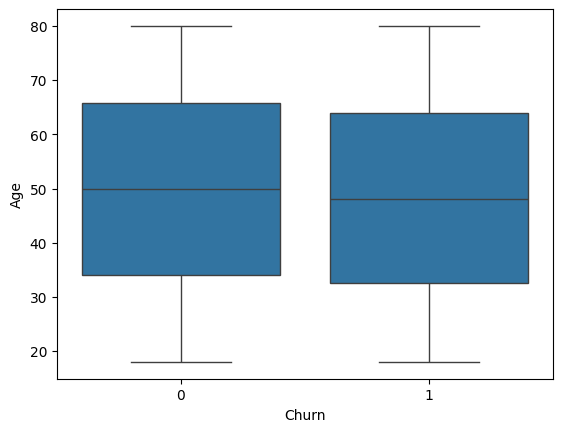

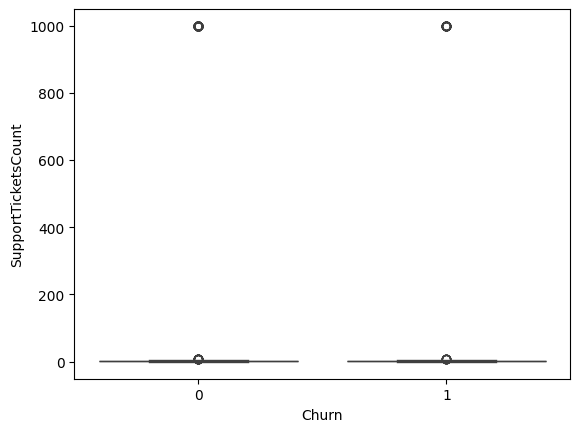

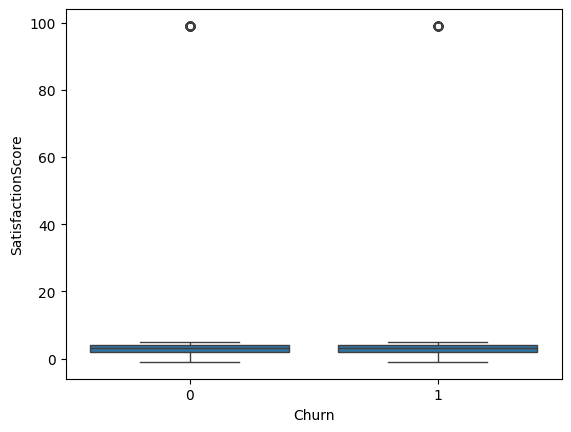

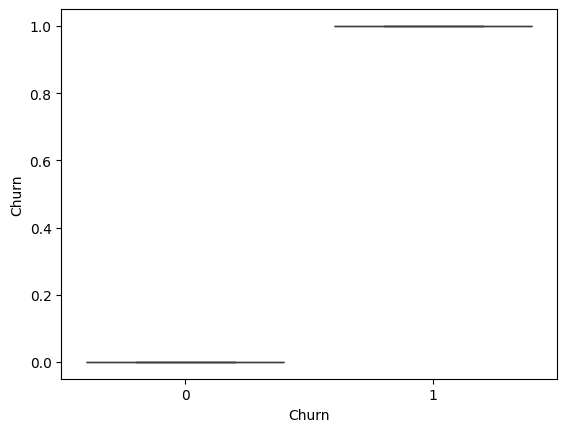

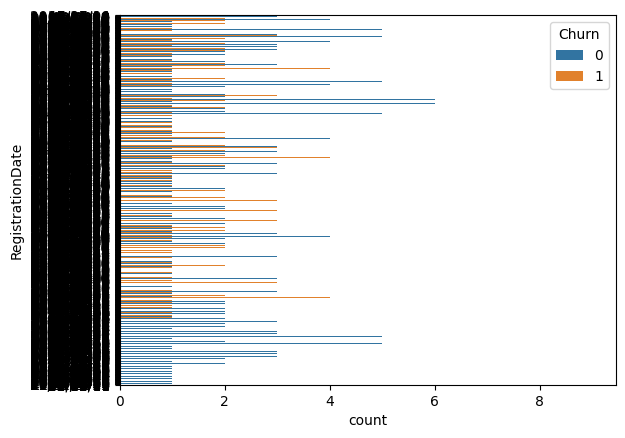

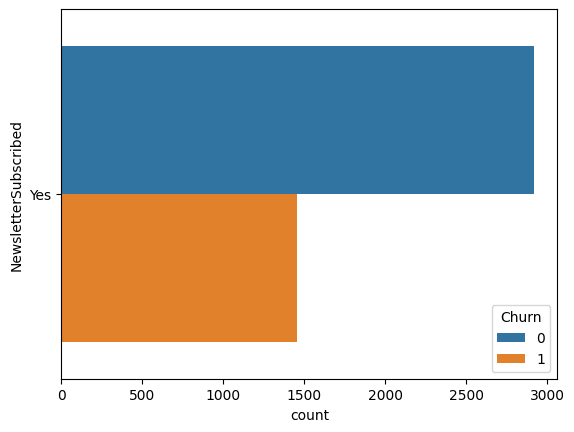

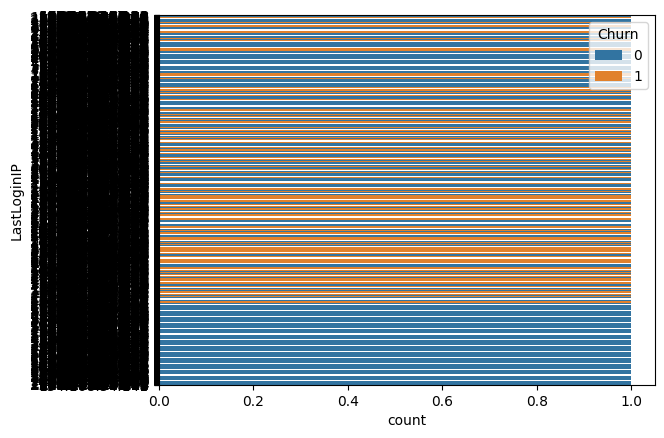

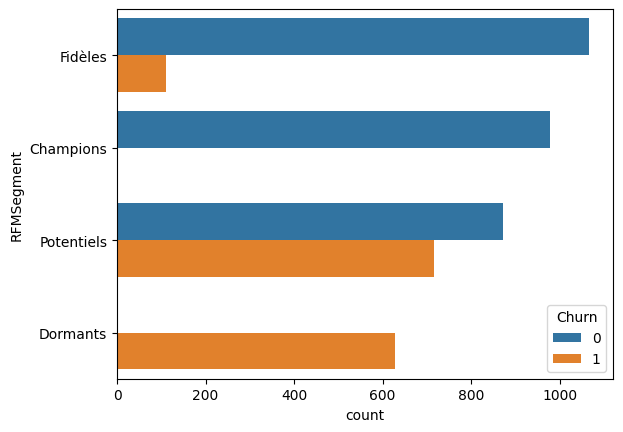

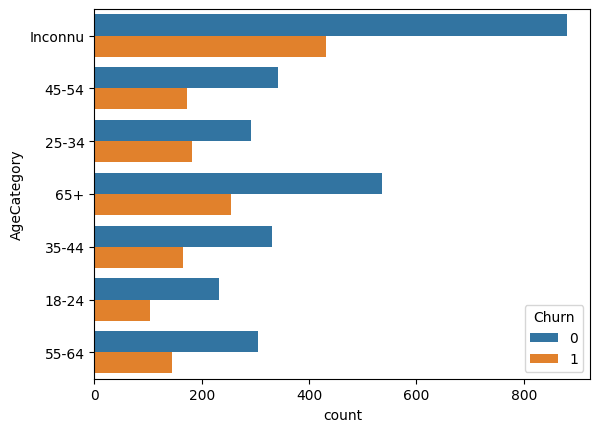

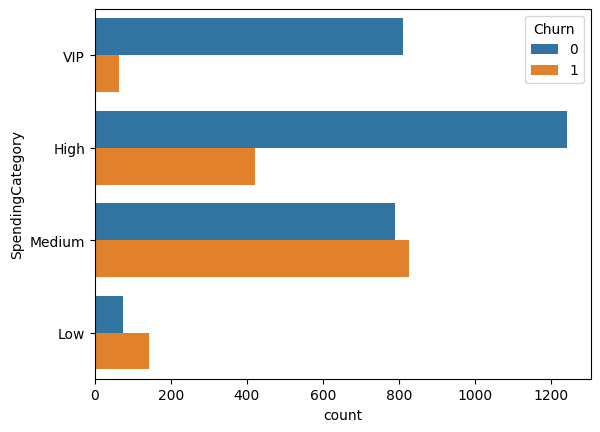

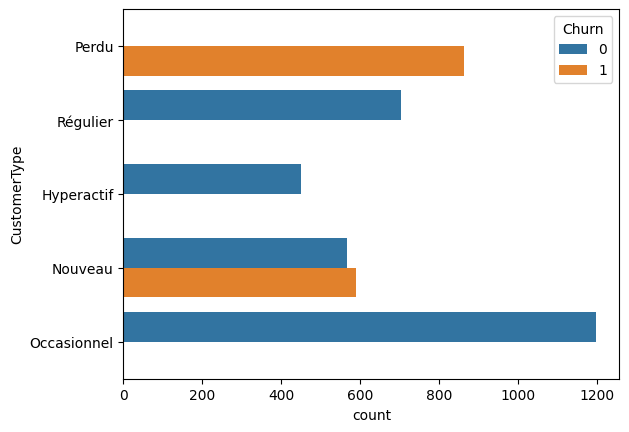

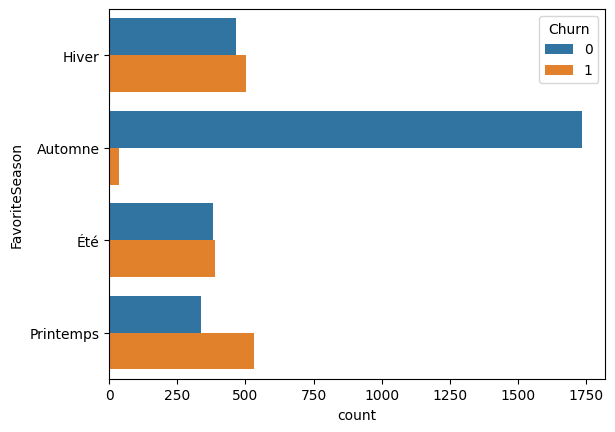

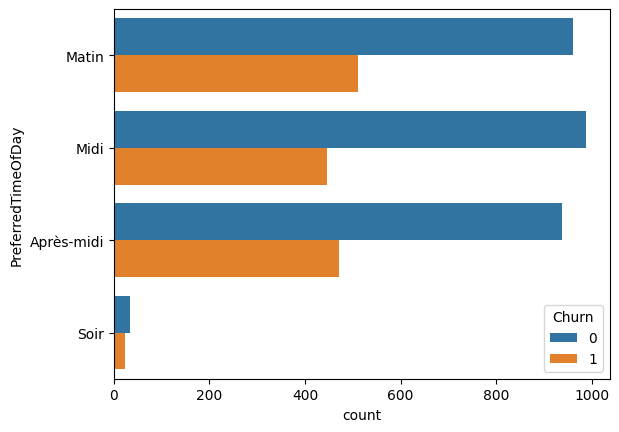

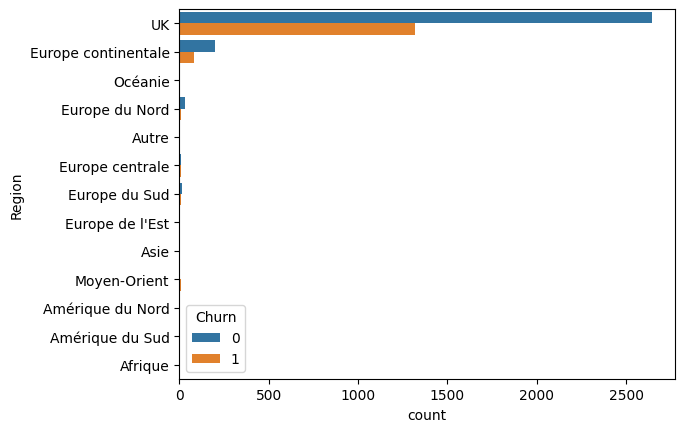

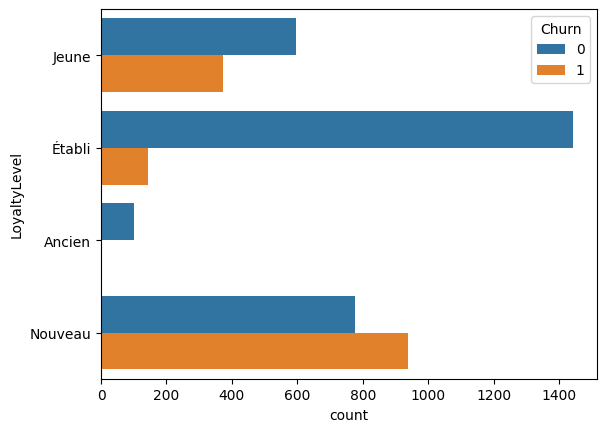

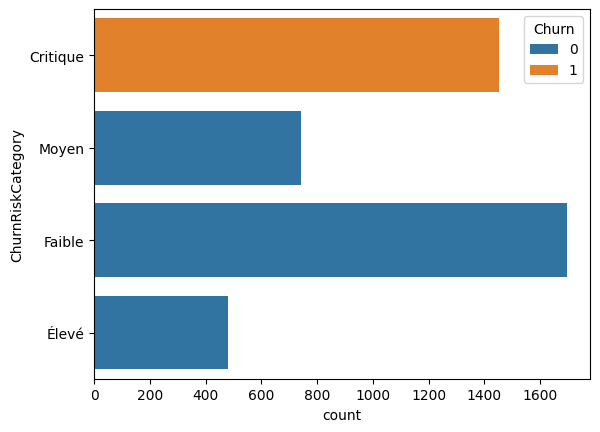

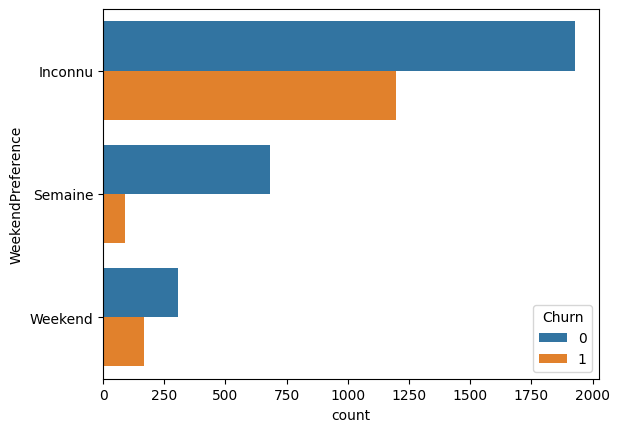

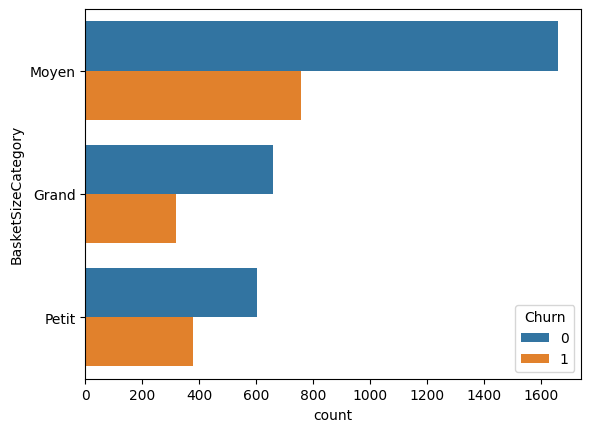

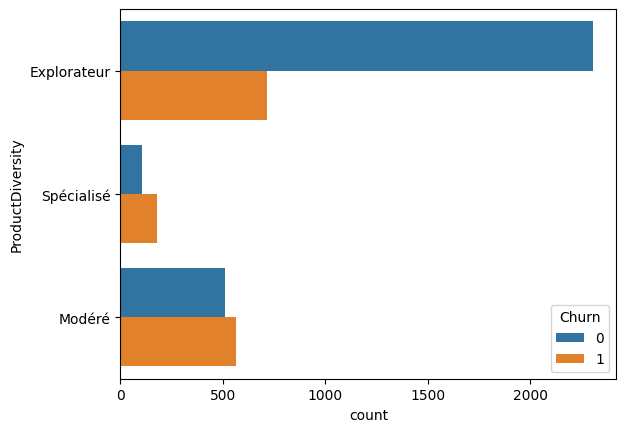

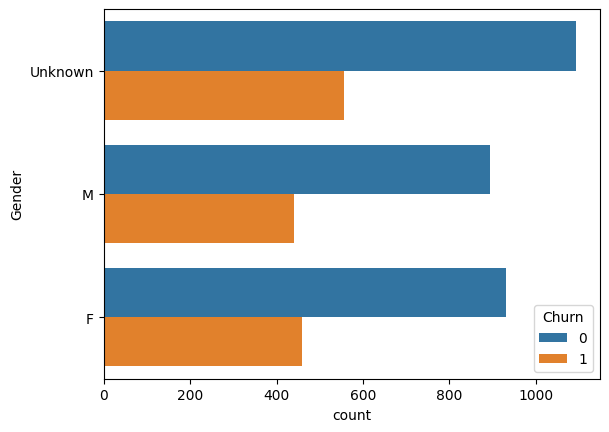

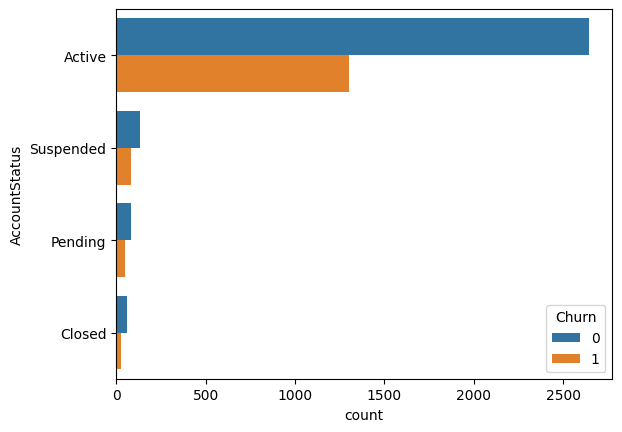

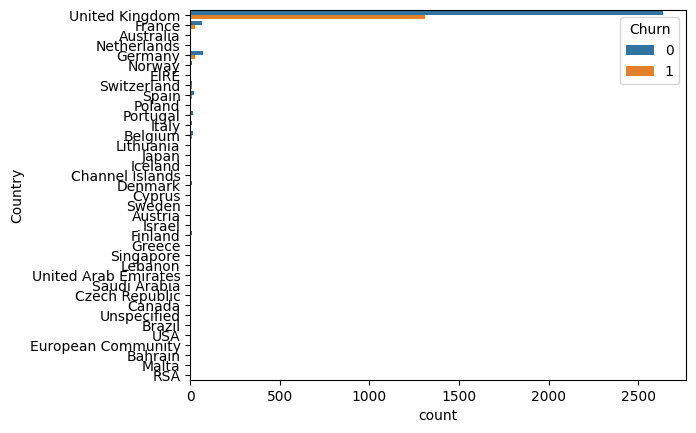

In [2]:
# notebooks/exploration.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données brutes
df = pd.read_csv("../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv")

# Aperçu
display(df.head())

# Infos générales
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Distribution de la target
sns.countplot(x="Churn", data=df)
plt.title("Répartition Churn")
plt.show()

# Statistiques sur features numériques
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features.remove("CustomerID")  # ID non pertinent
df[num_features].hist(bins=30, figsize=(15,10))
plt.show()

# Matrice de corrélation
plt.figure(figsize=(12,10))
sns.heatmap(df[num_features].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation entre features numériques")
plt.show()

# Analyse relations features vs target
for col in num_features:
    sns.boxplot(x="Churn", y=col, data=df)
    plt.show()

cat_features = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_features:
    sns.countplot(y=col, hue="Churn", data=df)
    plt.show()